## Liberias

In [325]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import recall_score, classification_report, roc_auc_score, average_precision_score, f1_score, precision_score, accuracy_score, confusion_matrix
import optuna
import numpy as np
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner


## DESCARGA DEL DATASET

In [271]:
df = pd.read_csv('fraud_oracle.csv')

In [272]:
df.head()
df.info() # No falta ningun dato por ahora tal vez veamos algunos nulls mas adelante

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

## Mirar y entender los datos dentro de cada variable

In [273]:
df.dtypes
df.dtypes.value_counts()


object    24
int64      9
Name: count, dtype: int64

In [274]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [275]:
def funcion(col):
    x=df[col].value_counts()
    return x 
funcion('Month') # balanceado los meses mes en que chocaron STR 
funcion('WeekOfMonth') # balanceado las semanas menos la 5 (hay menos) week en que chocaron INT (1 al 5)
funcion('DayOfWeek') # balancead los dias dia en que chocaron STR (Lunes a Domingo)
funcion('Make') # Marca del auto STR
funcion('AccidentArea') # Urbano (13822) vs Rural (1598) STR
funcion('DayOfWeekClaimed') # me imagino que es cuando se hace el reclamo STR
funcion('MonthClaimed') # mes en que se hizo el reclamo (hay uno que es 0 ver ) STR
#df.loc[df['MonthClaimed'] == '0' ,'MonthClaimed'] =  completarlo despues 
funcion('WeekOfMonthClaimed') # mes en que se hizo el reclamo (hay uno que es 0 ver ) INT (1 al 5)
#df.loc[df['DayOfWeekClaimed'] == '0' ,'DayOfWeekClaimed'] completarlo despues
funcion('Sex') # 13000 M y 2420 F STR
funcion('MaritalStatus') # # 10625 married, 4684 single 76 divorced 35 widowed STR
df['Age'].describe() # min 0  max 80 hay 320 filas con 0 anios INT Histograma
funcion('Fault') # 11230 Policy Holder (de la persona que reclamo) y 4190 Third Party (de la otra persona) STR
funcion('PolicyType') # Crear una nueva columna limpia que sea Colission/liability/all perils STR
funcion('VehicleCategory') # Sedan Sport Utility STR
funcion('VehiclePrice') # Es STR (Malo para analisis)
funcion('FraudFound_P') # 0--> No Fraud 14497 1--> Fraud 923 INT (bool) Variable a predecir 0.94 No Fraud 0.06 Fraud
df['PolicyNumber'].nunique(dropna=False)# Son todos unicos INT
funcion('RepNumber') #RepNumber es un identificador numérico del representante o agente encargado de gestionar cada reclamo.
funcion('Deductible') # 400 700 500 y 300 int el monto fijo que el asegurado paga de su bolsillo antes de que el seguro cubra el resto del reclamo.
funcion('DriverRating') # 1 al 4 int (Inchequeable de donde lo sacaron)
funcion('Days_Policy_Accident') # Dias entre la fecha del accidente y la fecha en que se adquirio la poliza. Es STR (MALO PARA ANALISIS) hay 55 none
funcion('Days_Policy_Claim') # Dias entre la fecha del reclamo y la fecha en que presento el reclamo Es STR (MALO PARA ANALISIS) hay 1 none
funcion('PastNumberOfClaims') # Numero de reclamos de la persona. STR (MALO PARA ANALISIS)
funcion('AgeOfVehicle') # Edad del vehiculo STR (MALO PARA ANALISIS) 
funcion('AgeOfPolicyHolder') # Edad del titular de la poliza. STR (MALO PARA ANALISIS)
funcion('PoliceReportFiled') # Si se presento un informe policial no(14992) si(428) STR
funcion('WitnessPresent') # Si hubo testigos no(15333) si(87) STR
funcion('AgentType') # Tipo de agente que gestiono el reclamo. External (15179) Internal (241) STR
funcion('NumberOfSuppliments') # NumberOfSuppliments indica cuántas veces el reclamo fue modificado después de haber sido presentado inicialmente. STR (MALO PARA ANALISIS)
funcion('AddressChange_Claim') # AddressChange_Claim indica cuánto tiempo ha pasado desde que el titular de la póliza cambió de domicilio al momento de presentar el reclamo. STR(Malo PARA ANALISIS)
funcion('NumberOfCars') # Cuántos vehículos tiene registrados el titular de la póliza. STR (MALO PARA ANALISIS)
funcion('Year') # Año en el que se registró el reclamo 1994 1996

Year
1994    6142
1995    5195
1996    4083
Name: count, dtype: int64

In [276]:
df.drop(columns='PolicyNumber',inplace=True) # Eliminamos columna irrelevantes

In [277]:
df.duplicated().sum() # No hay filas duplicadas

np.int64(0)

## Limpieza de variables

In [278]:
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
day_map = {'Monday':1 ,'Tuesday':2,'Wednesday':3,'Thursday':4, 'Friday':5,'Saturday':6,'Sunday':7}

df['Month'] = df['Month'].map(month_map)
df['DayOfWeek'] = df['DayOfWeek'].map(day_map)
df['DayOfWeekClaimed'] = df['DayOfWeekClaimed'].map(day_map)
df['MonthClaimed'] = df['MonthClaimed'].map(month_map)


In [279]:
df_base = df.copy()

# Modelo Baseline

In [ ]:
target_base = 'FraudFound_P'
X_base = df_base.drop(columns=[target_base])
y_base= df_base[target_base]

# Columnas categóricas
cat_features_base = X_base.select_dtypes(include=['object', 'category']).columns.tolist()

# Train-test split
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

# Pools
train_pool = Pool(data=X_train_base, label=y_train_base, cat_features=cat_features_base)
test_pool = Pool(data=X_test_base, label=y_test_base, cat_features=cat_features_base)

# Modelo CatBoost optimizado para Recall
model_base = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced', #esto hace que ra recall de 1 sea excelente pero las otras metricas bajen
    eval_metric='Recall',       # 🔥 acá cambiamos la métrica
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

model_base.fit(train_pool, eval_set=test_pool)

# Predicciones
y_pred_base = model_base.predict(X_test_base)

# Métrica importante
print("Recall:", recall_score(y_test_base, y_pred_base))
print(classification_report(y_test_base, y_pred_base))


0:	test: 0.7734074	best: 0.7734074 (0)	total: 292ms	remaining: 4m 51s
100:	test: 0.8581654	best: 0.8582885 (96)	total: 9.98s	remaining: 1m 28s
200:	test: 0.8658009	best: 0.8667500 (175)	total: 20.2s	remaining: 1m 20s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8667499511
bestIteration = 175

Shrink model to first 176 iterations.
Recall: 0.9459459459459459
              precision    recall  f1-score   support

           0       0.99      0.68      0.80      2899
           1       0.16      0.95      0.27       185

    accuracy                           0.69      3084
   macro avg       0.58      0.81      0.54      3084
weighted avg       0.94      0.69      0.77      3084



In [ ]:
y_proba_base = model_base.predict_proba(X_test_base)[:, 1]

# Elegís el umbral que quieras (ejemplo: 0.51)
threshold = 0.5 # acá lo cambiás a gusto

# Clasificación manual con ese umbral
y_pred_custom_base = (y_proba_base >= threshold).astype(int)

# Métricas
print("AUC-PR:", average_precision_score(y_test_base, y_proba_base))  # OJO: AUC-PR va con proba, no con 0/1
print(classification_report(y_test_base, y_pred_custom_base))

AUC-PR: 0.27232451648125117
              precision    recall  f1-score   support

           0       0.99      0.68      0.80      2899
           1       0.16      0.95      0.27       185

    accuracy                           0.69      3084
   macro avg       0.58      0.81      0.54      3084
weighted avg       0.94      0.69      0.77      3084



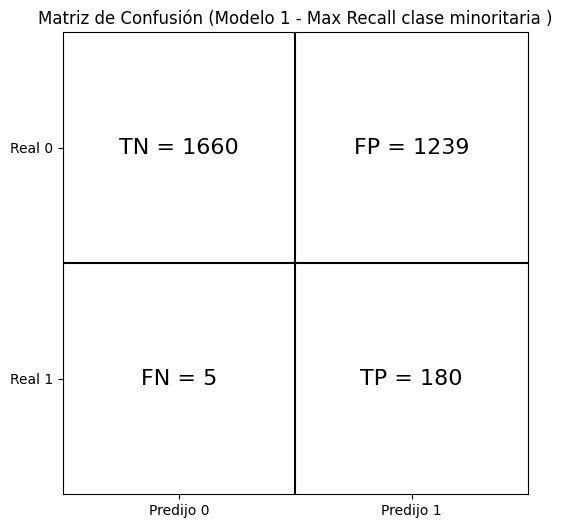

In [318]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_base, y_pred_custom_base)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 6))

# Líneas divisorias
ax.plot([0, 2], [1, 1], color='black')
ax.plot([1, 1], [0, 2], color='black')

# Etiquetas
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Predijo 0', 'Predijo 1'])
ax.set_yticklabels(['Real 0', 'Real 1'])

# Valores correctos en cada cuadrante
ax.text(0.5, 0.5, f"TN = {tn}", ha='center', va='center', fontsize=16)
ax.text(1.5, 0.5, f"FP = {fp}", ha='center', va='center', fontsize=16)
ax.text(0.5, 1.5, f"FN = {fn}", ha='center', va='center', fontsize=16)
ax.text(1.5, 1.5, f"TP = {tp}", ha='center', va='center', fontsize=16)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.invert_yaxis()

plt.title("Matriz de Confusión (Modelo 1 - Max Recall clase minoritaria )")
plt.show()


## Grafico para inspeccionar las variables

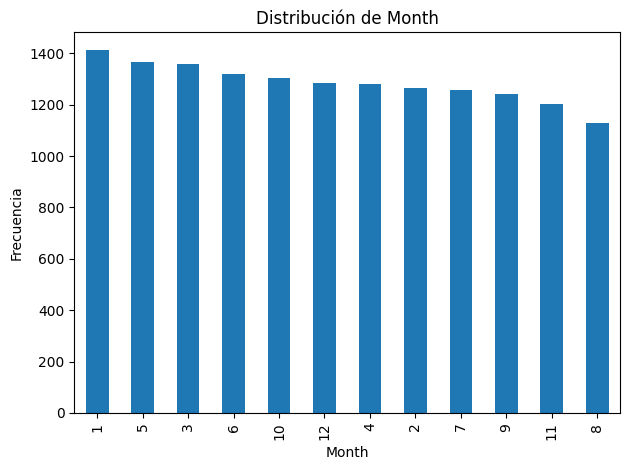

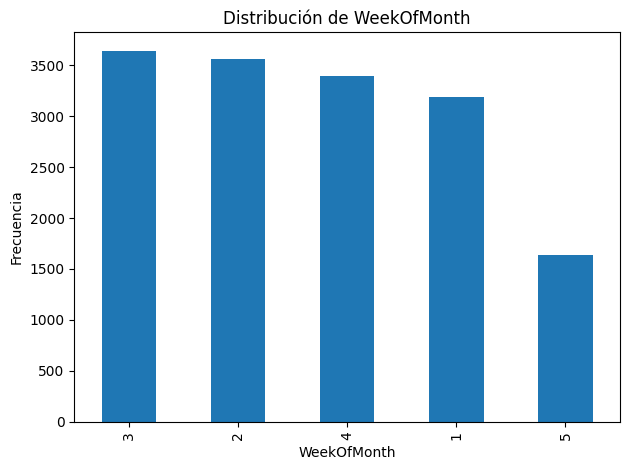

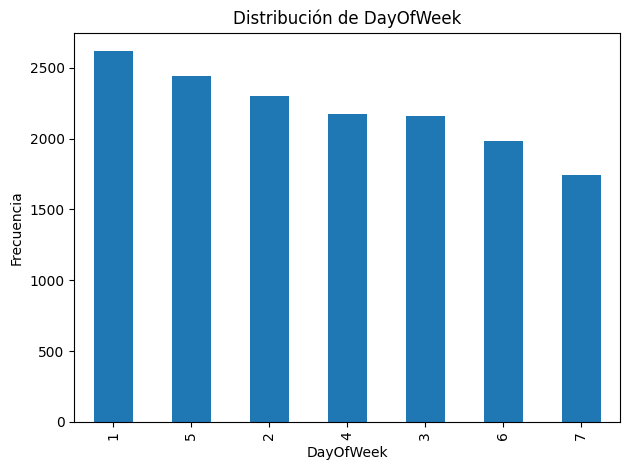

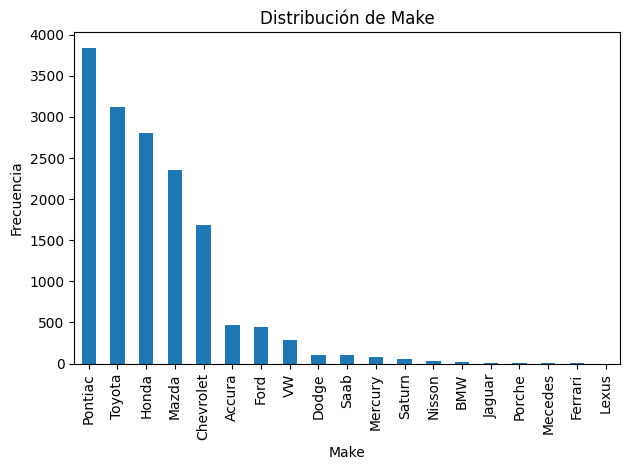

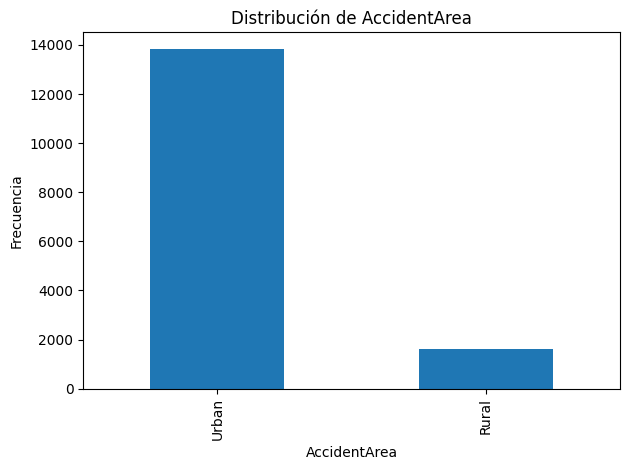

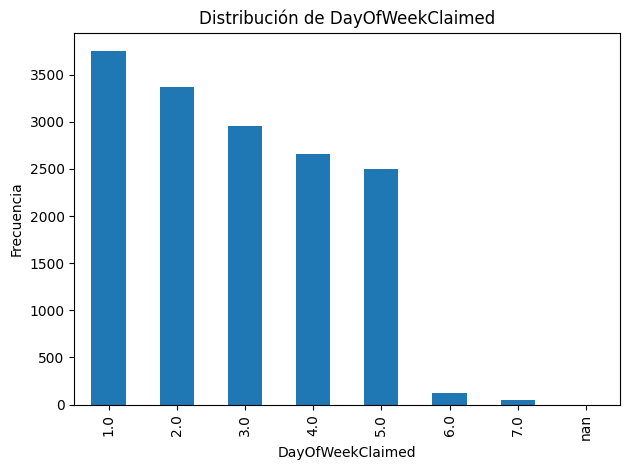

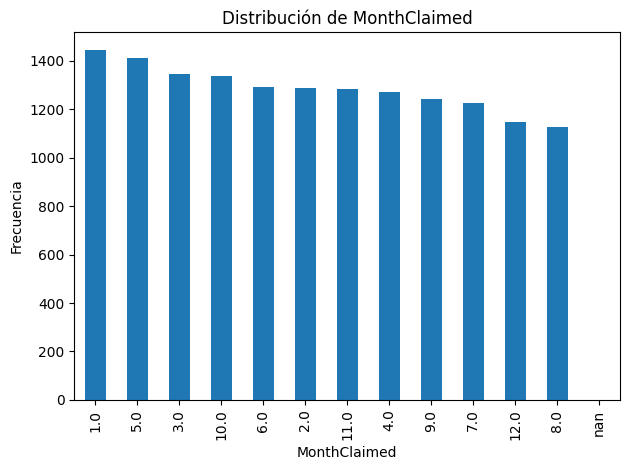

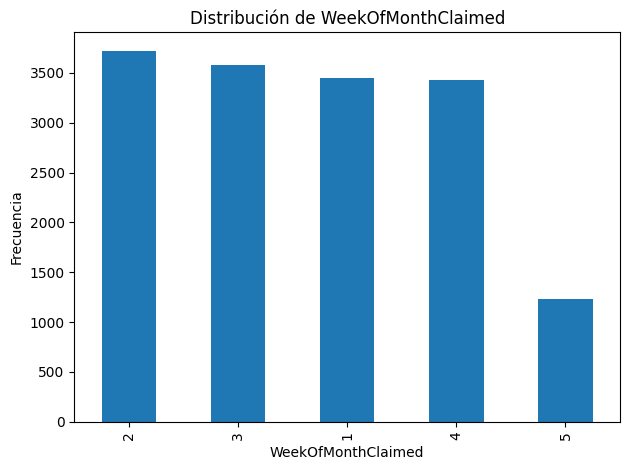

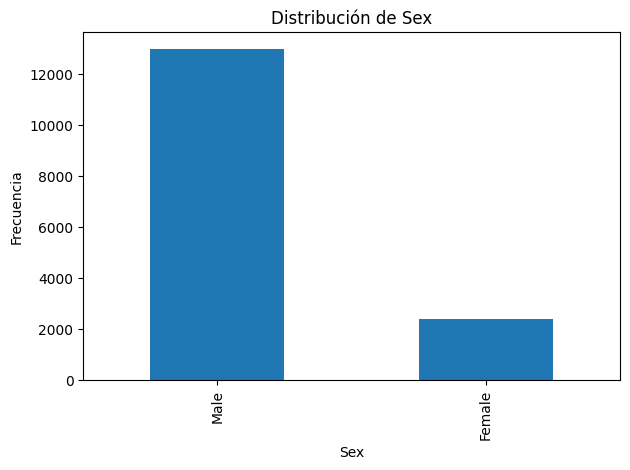

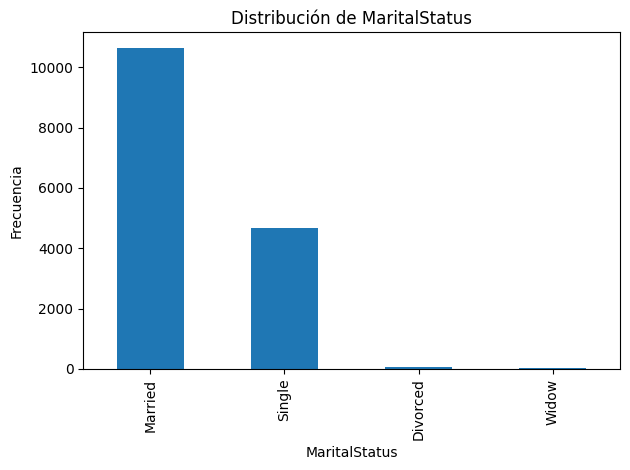

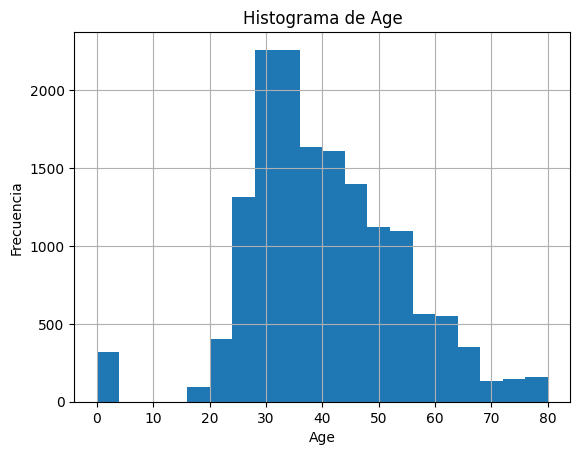

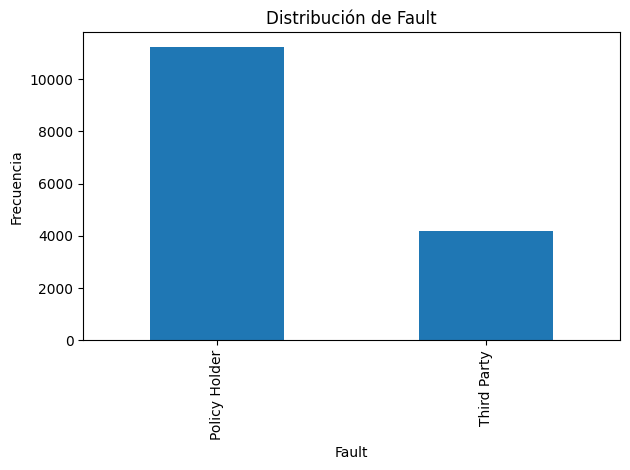

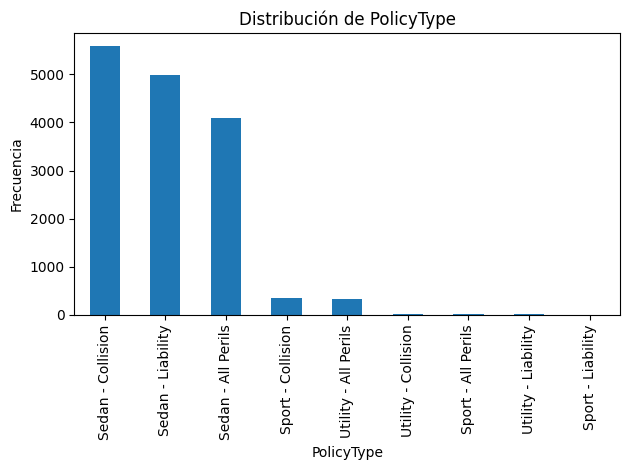

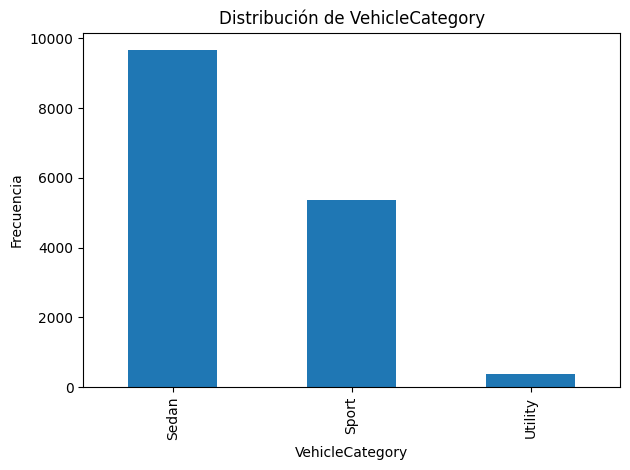

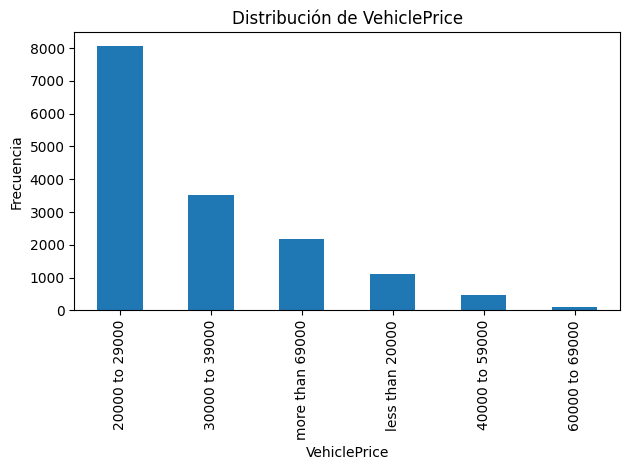

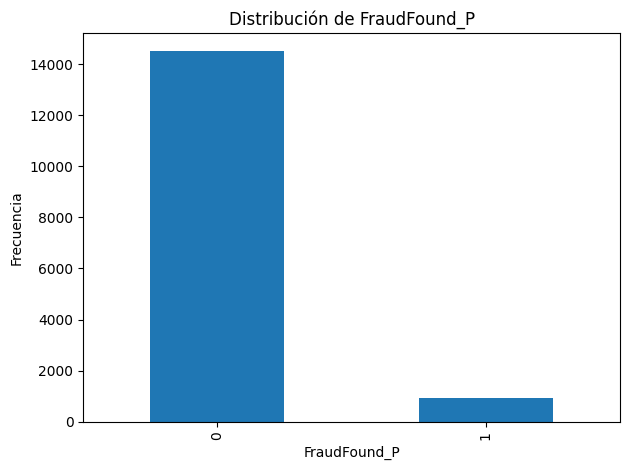

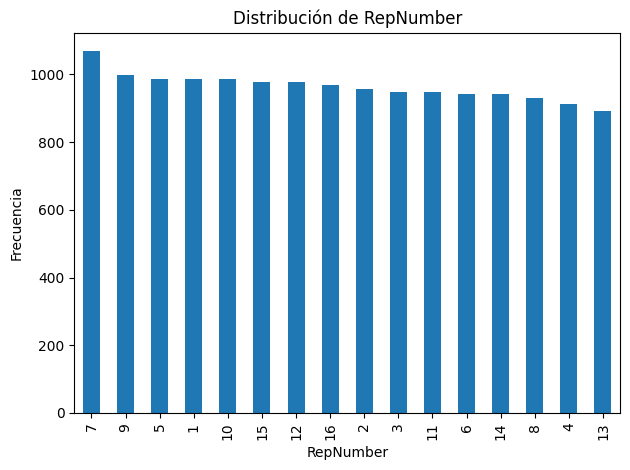

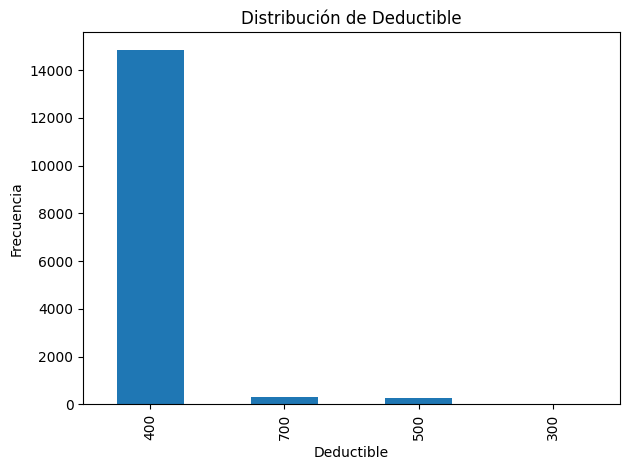

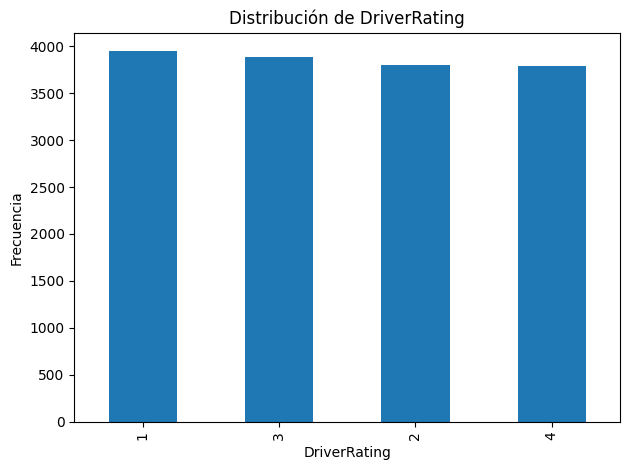

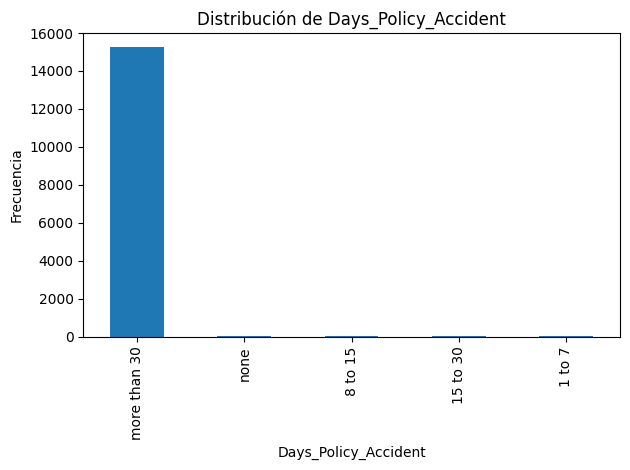

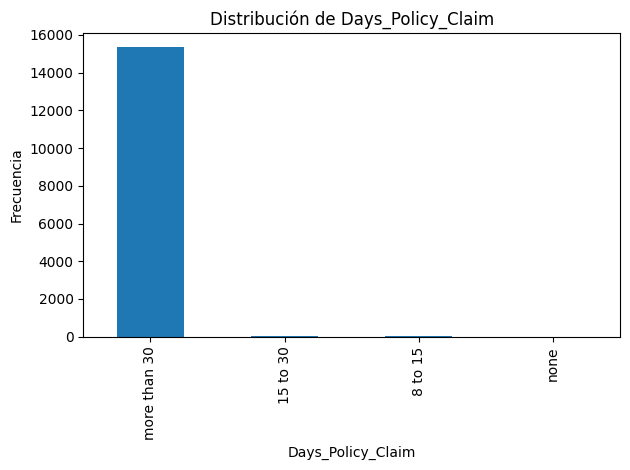

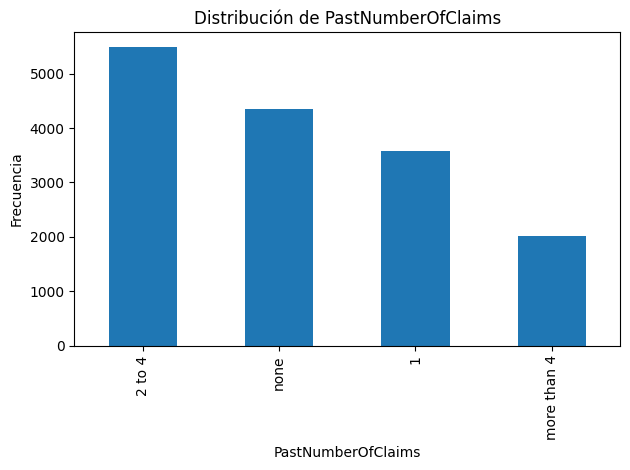

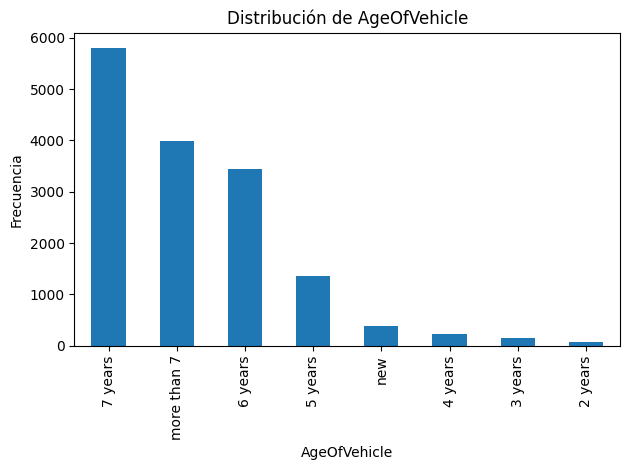

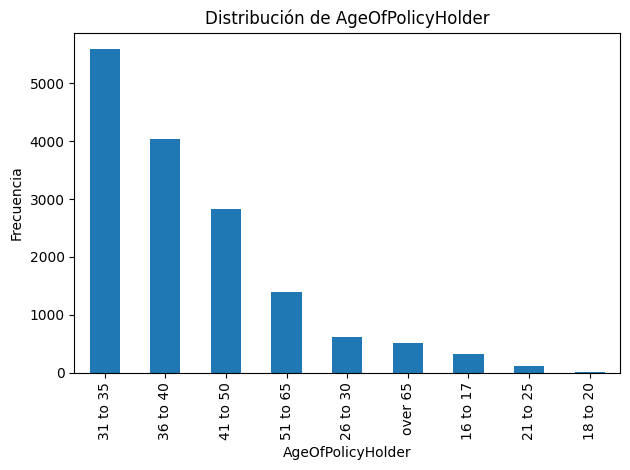

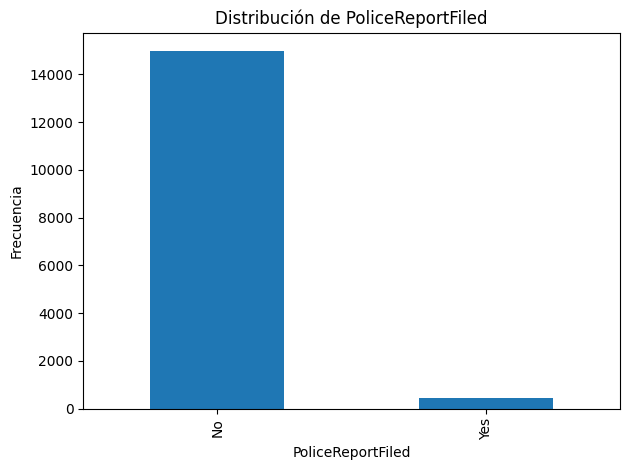

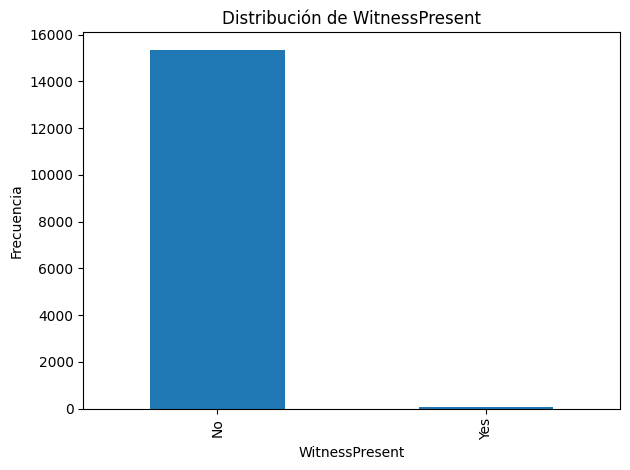

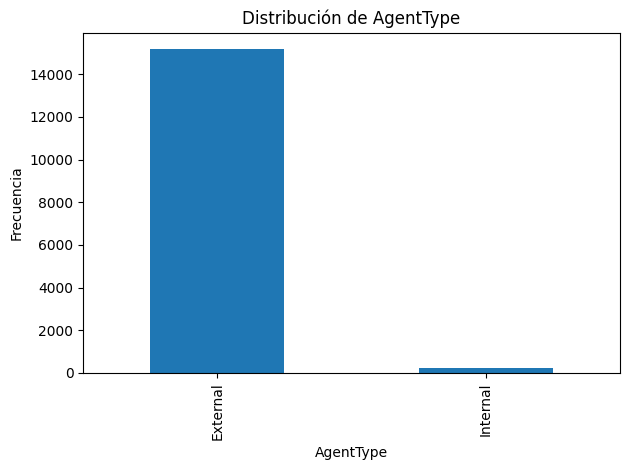

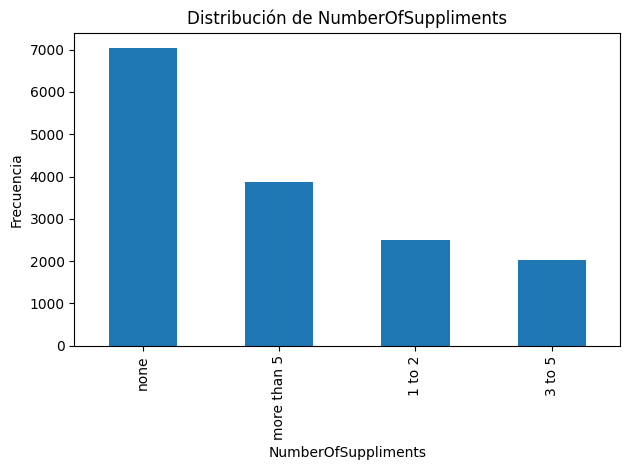

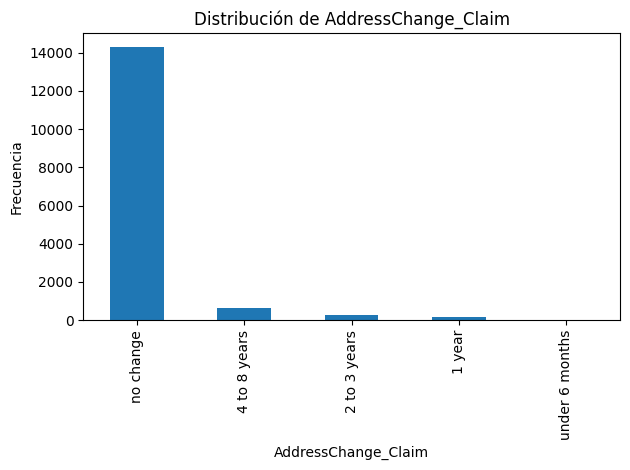

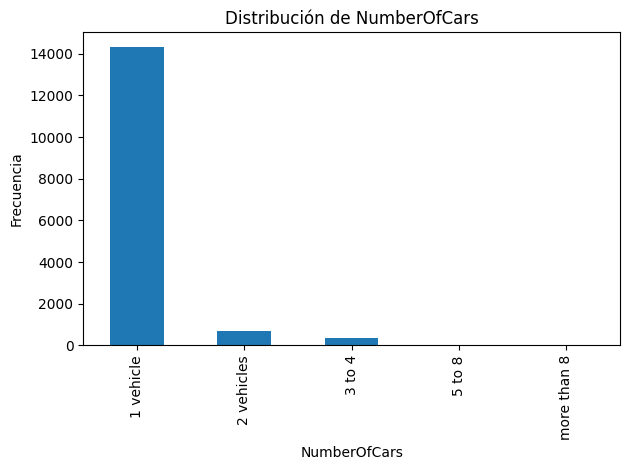

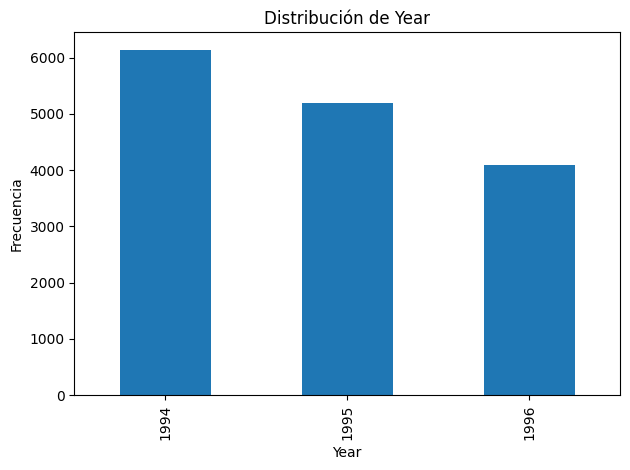

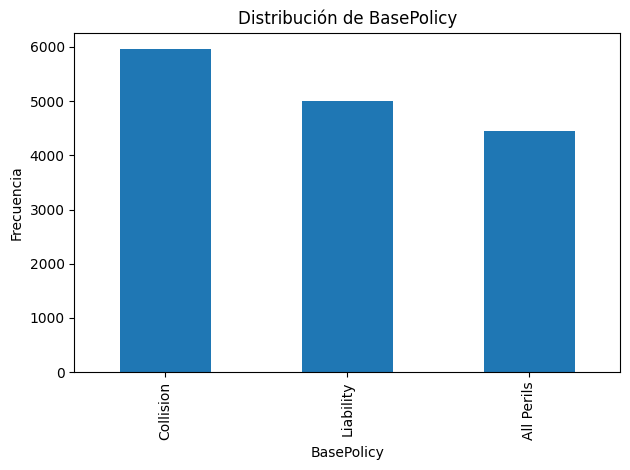

In [282]:
for col in df.columns:
    plt.figure()

    if col == "Age":
        # Histograma solo para Age
        df[col].dropna().hist(bins=20)
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

    else:
        # Gráfico de barras para TODAS las demás columnas
        df[col].value_counts(dropna=False).plot(kind="bar")
        plt.title(f"Distribución de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()

    plt.show()


Graficos para ver la frecuencia con Fraude=1 y Fraude=0

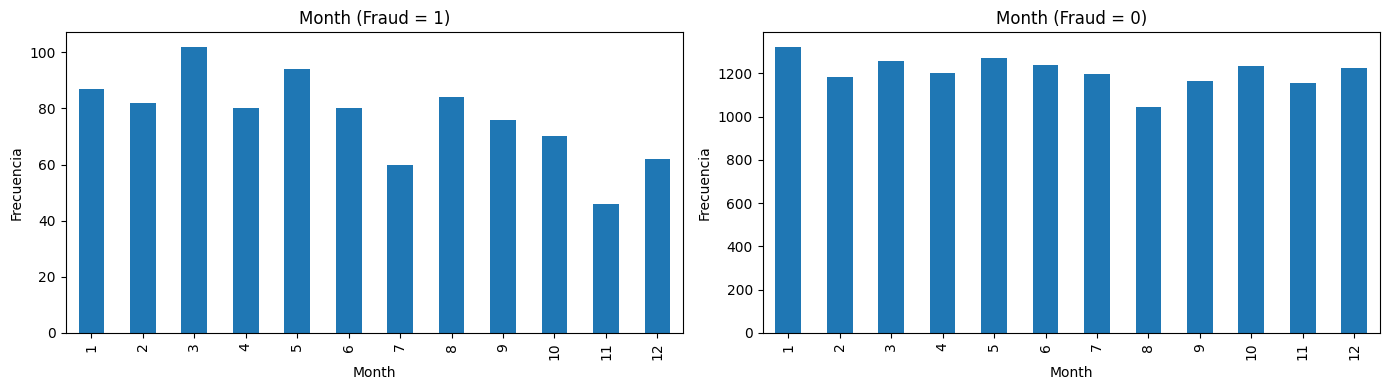

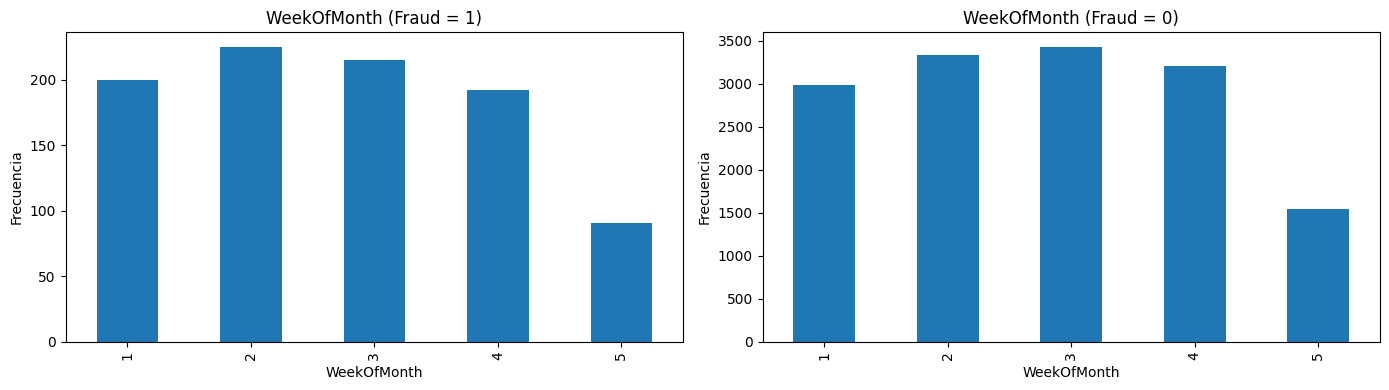

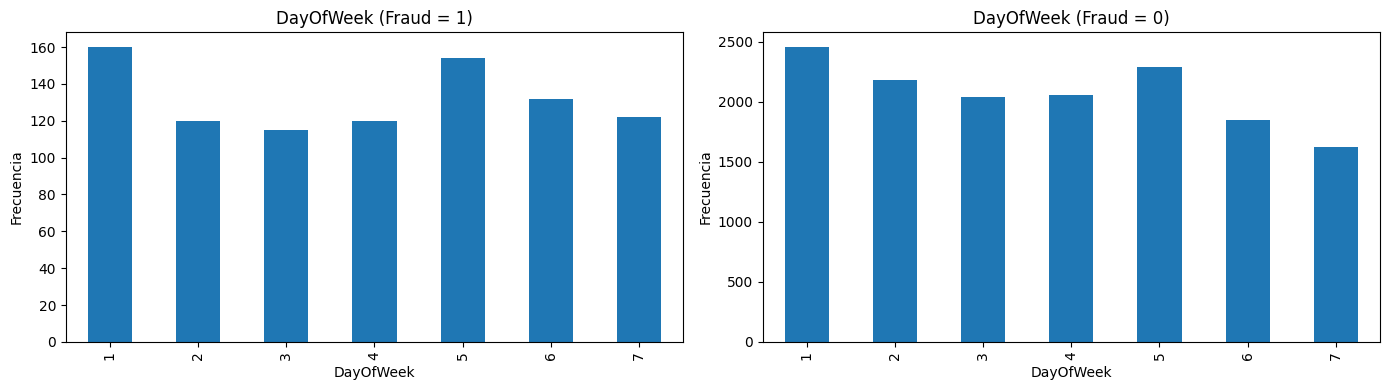

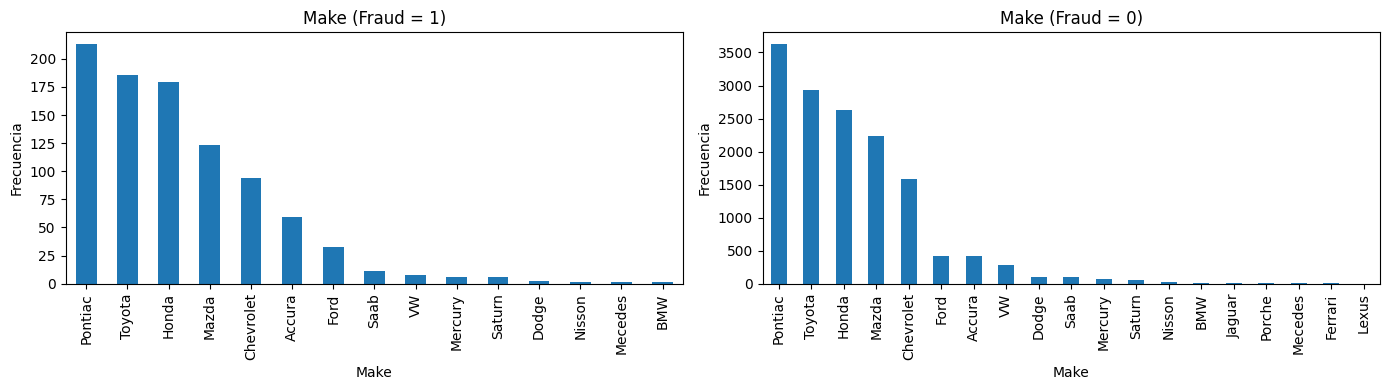

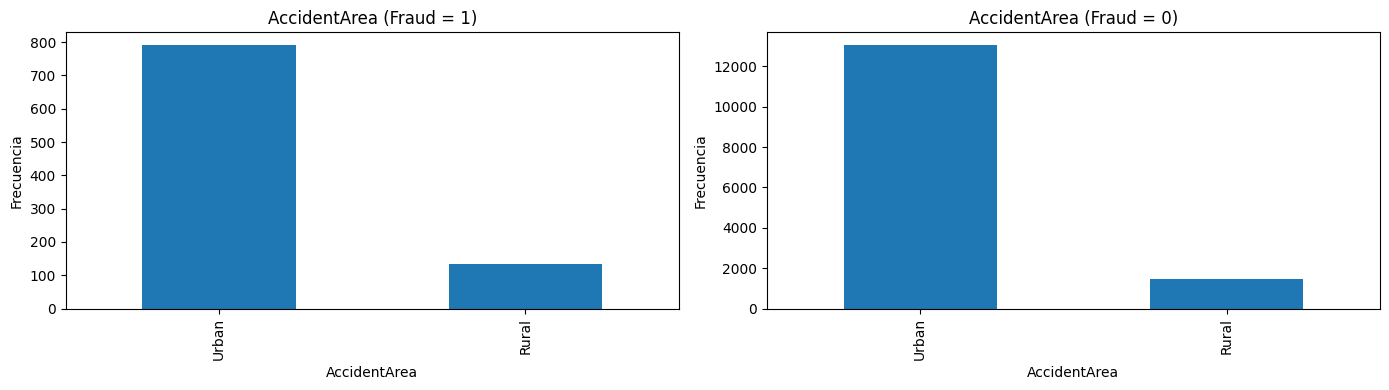

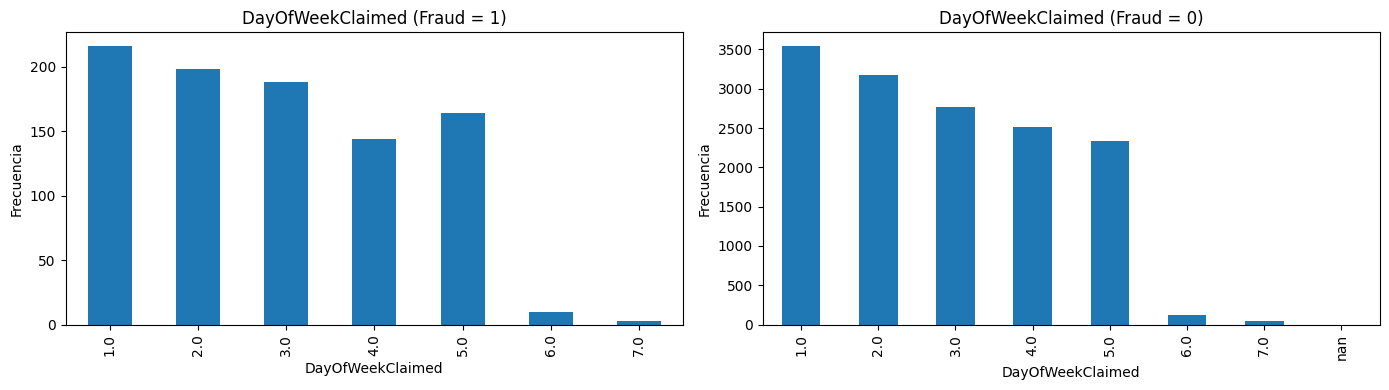

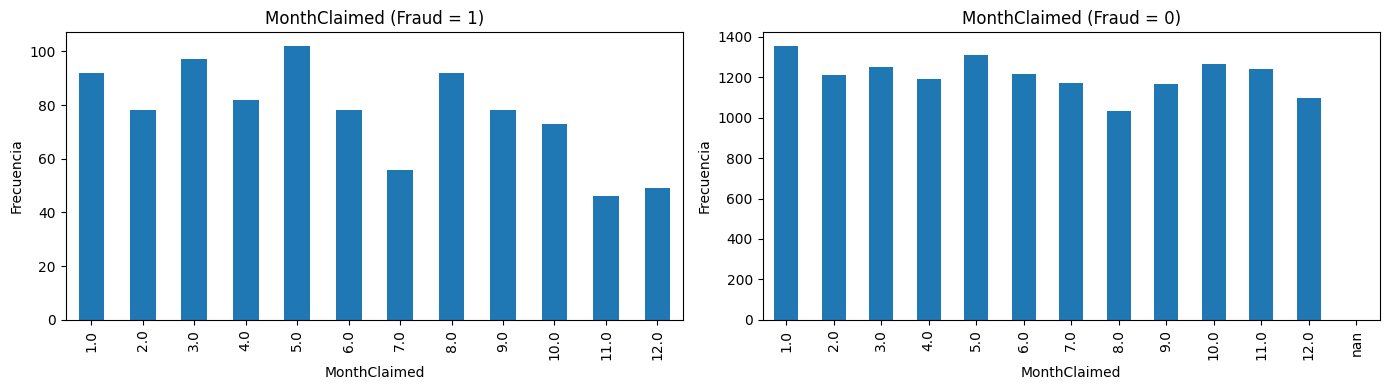

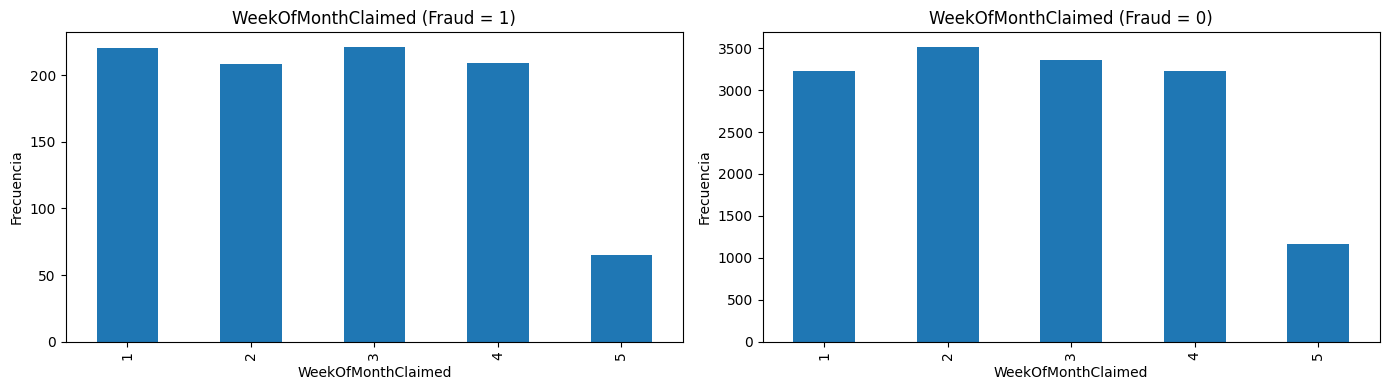

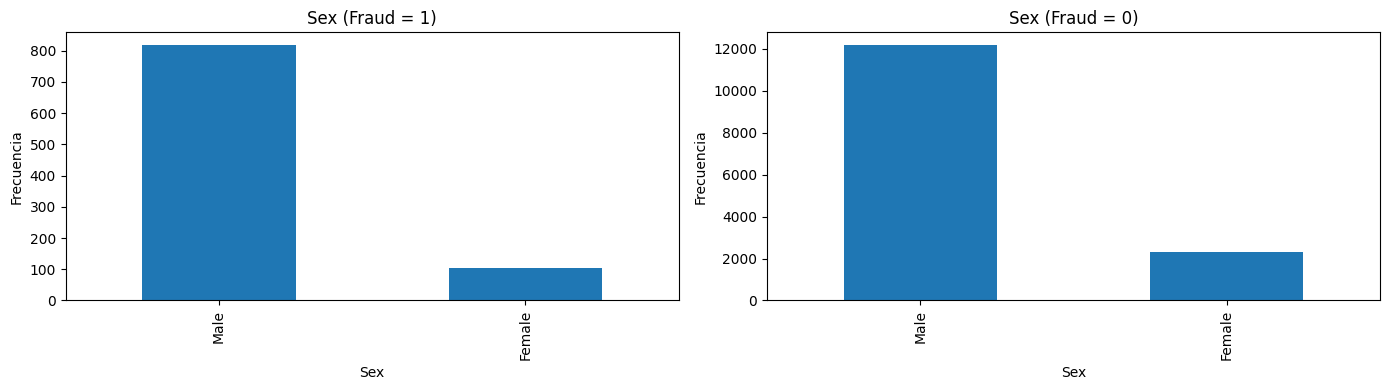

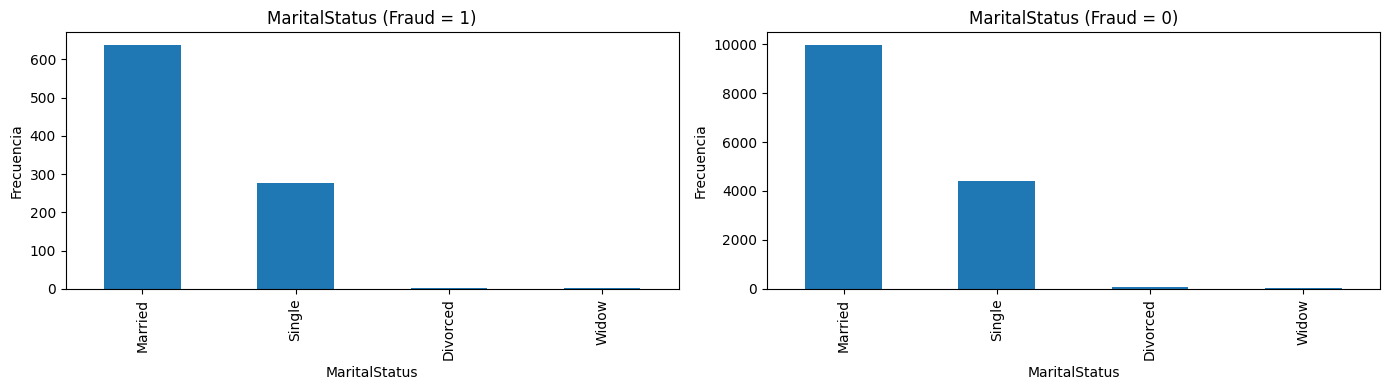

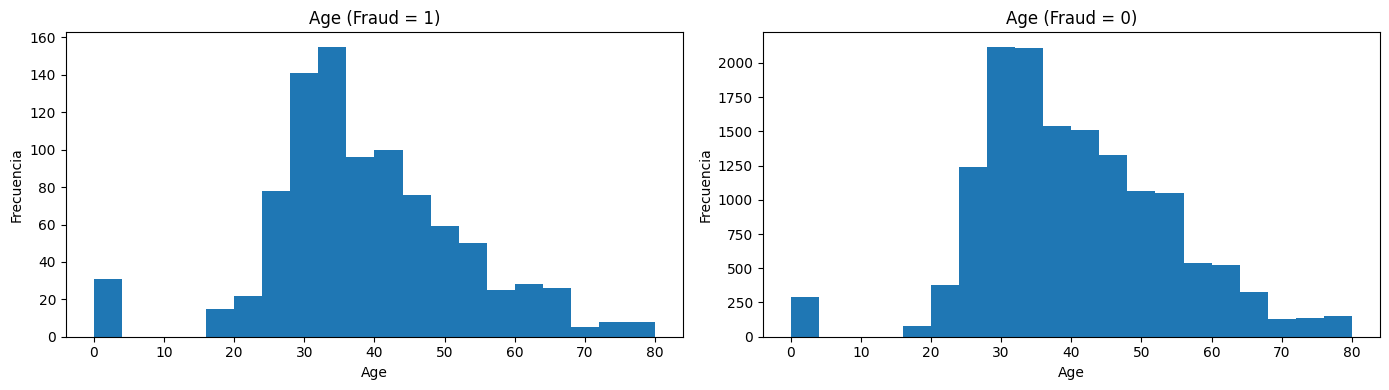

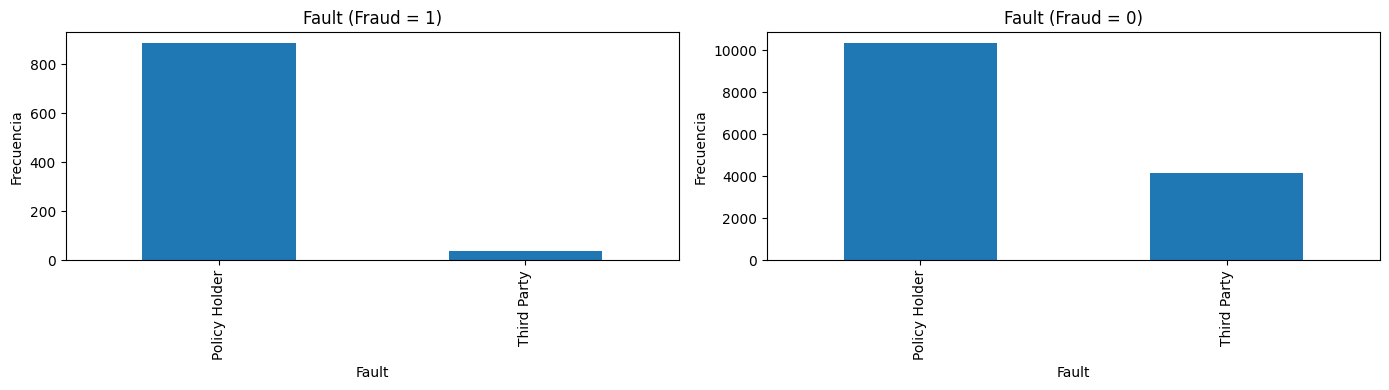

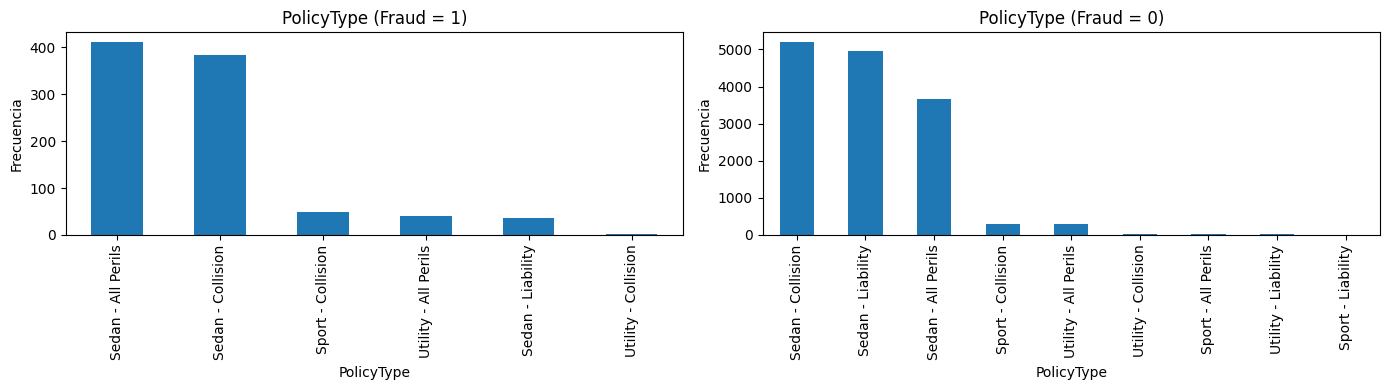

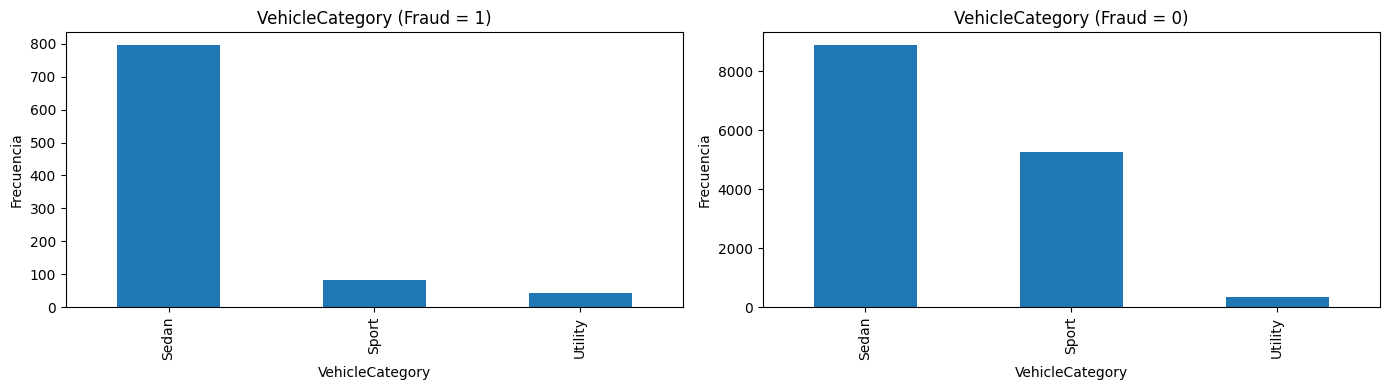

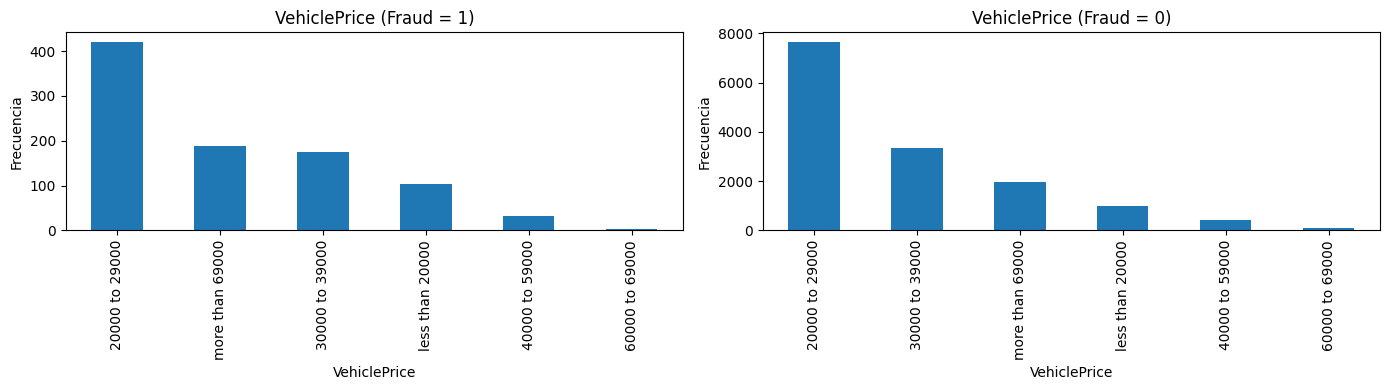

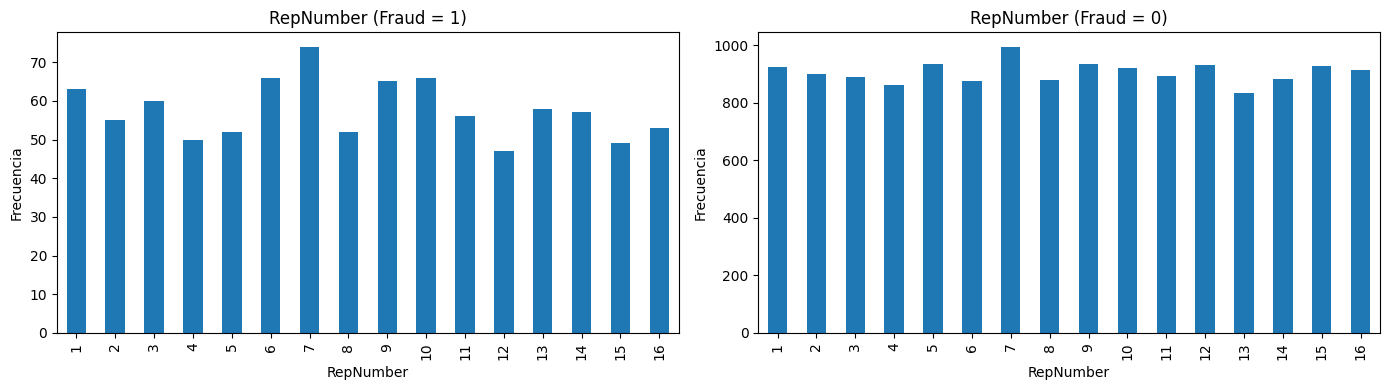

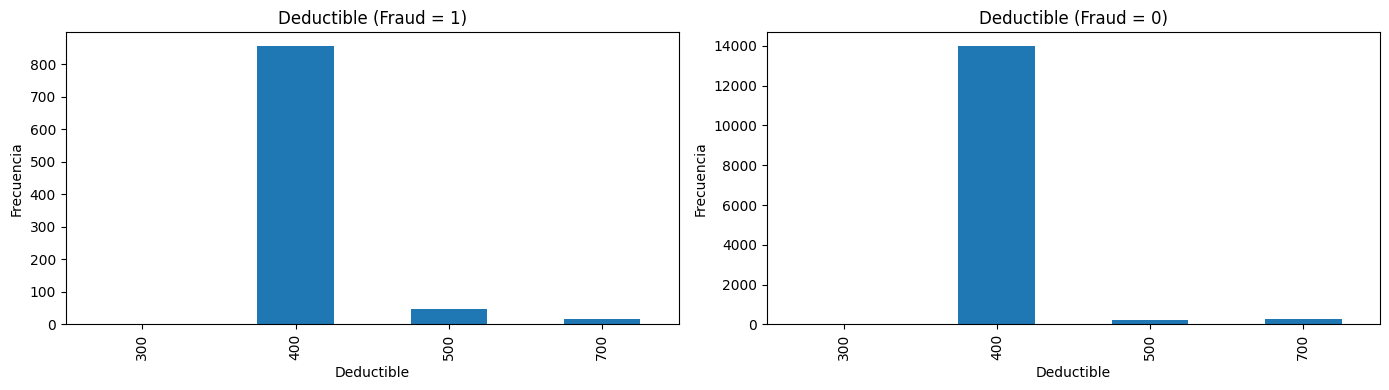

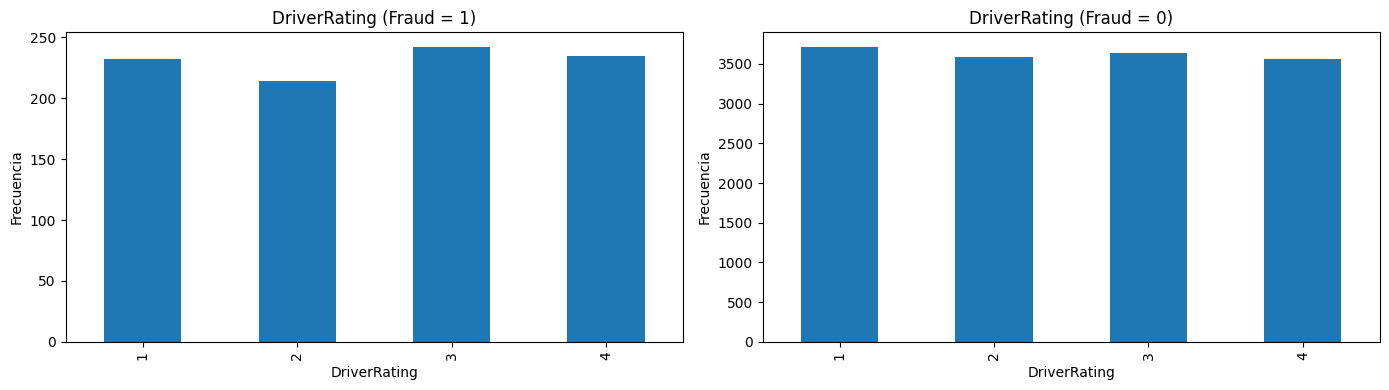

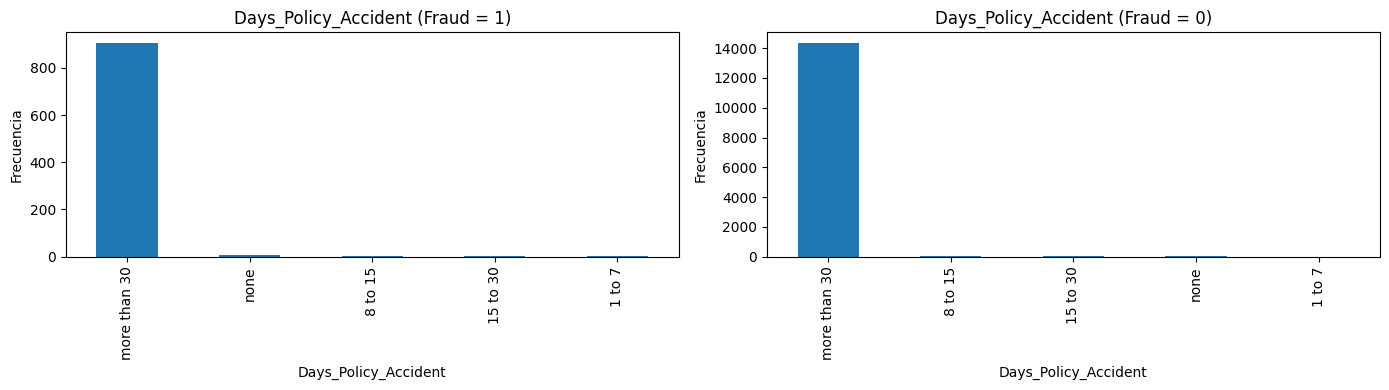

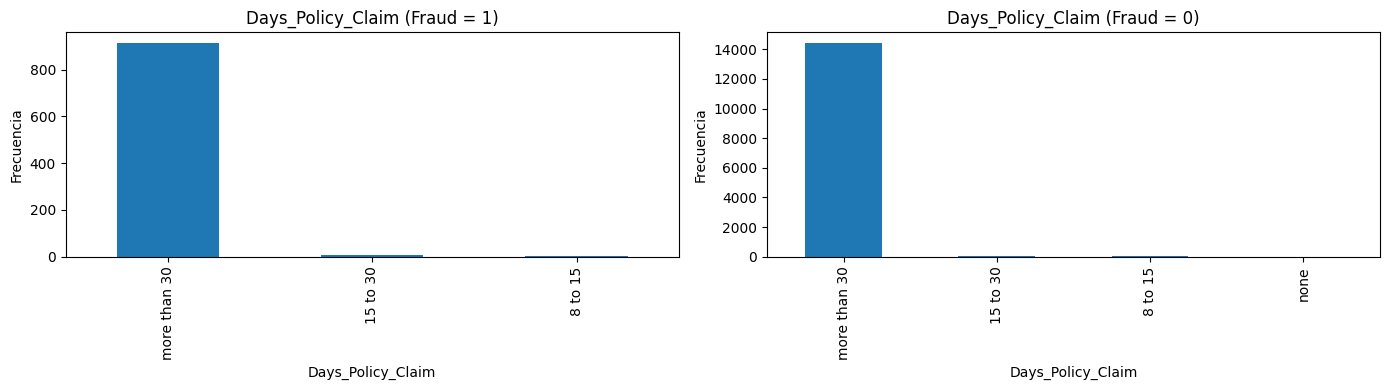

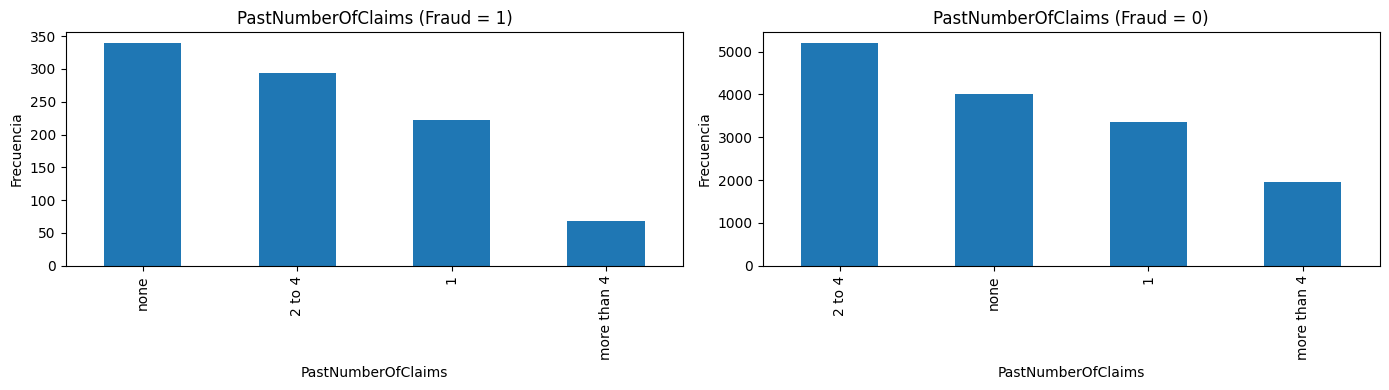

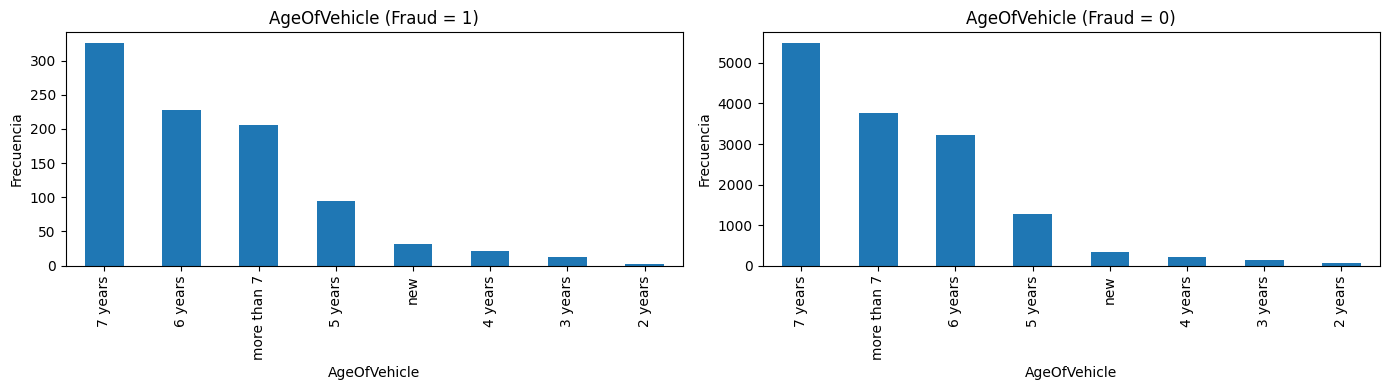

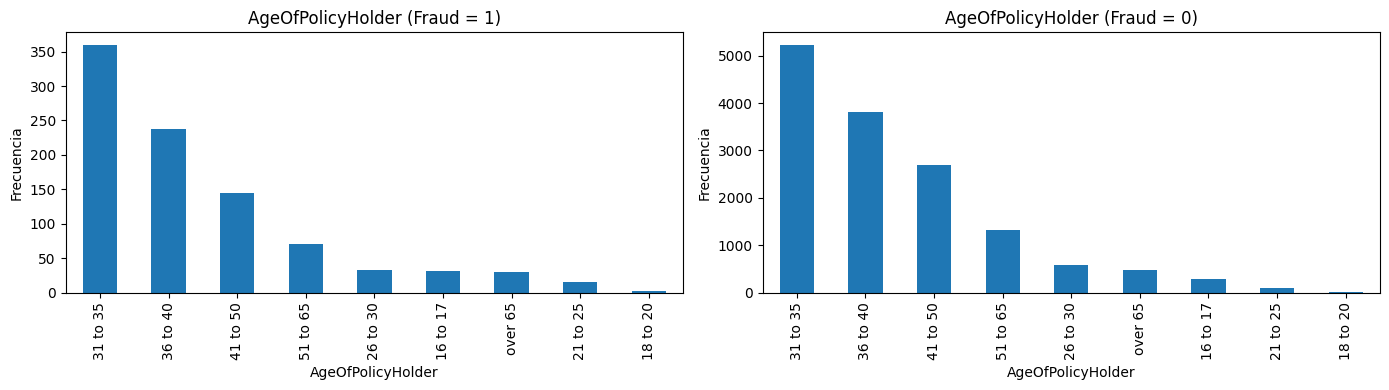

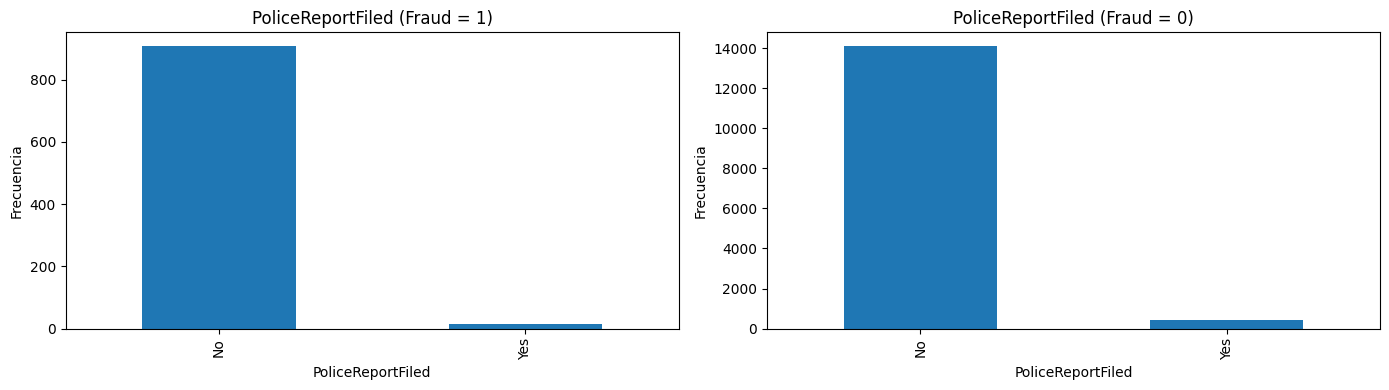

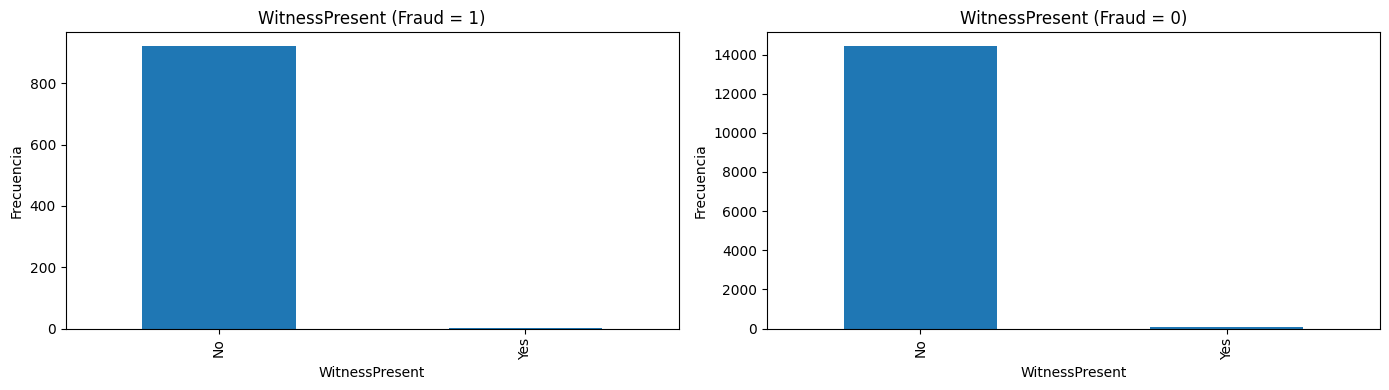

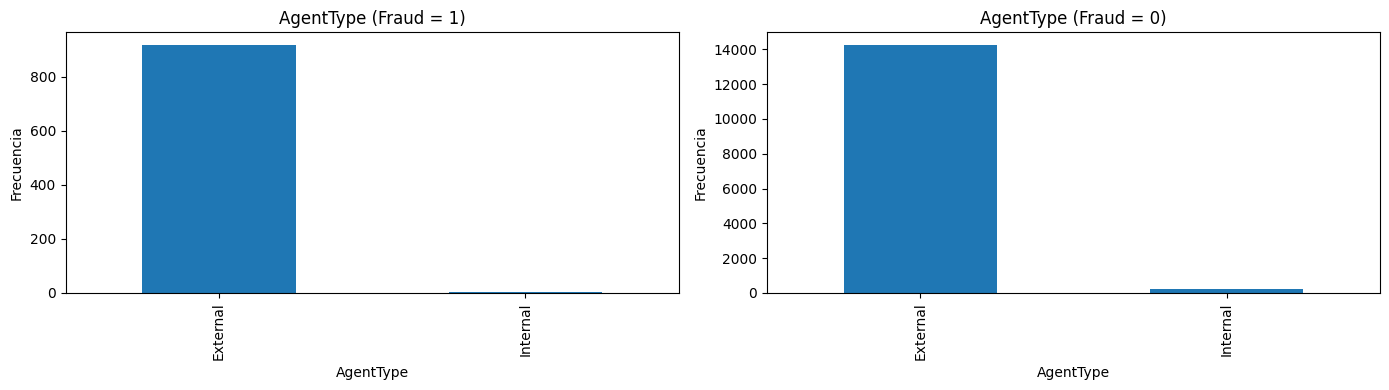

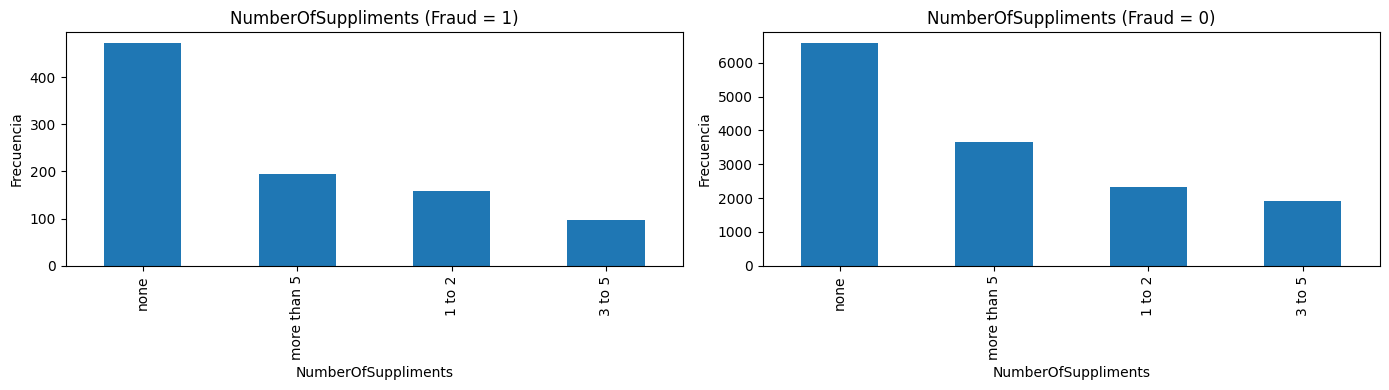

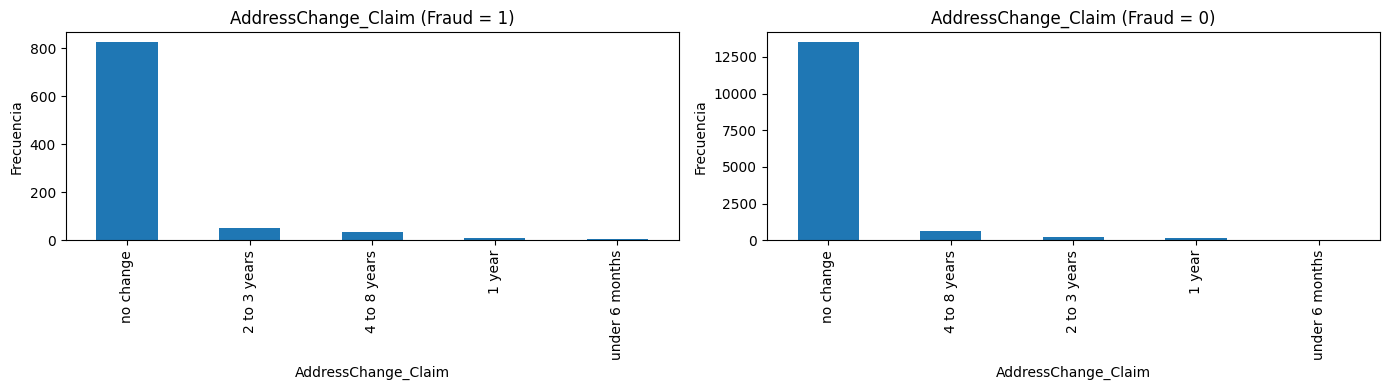

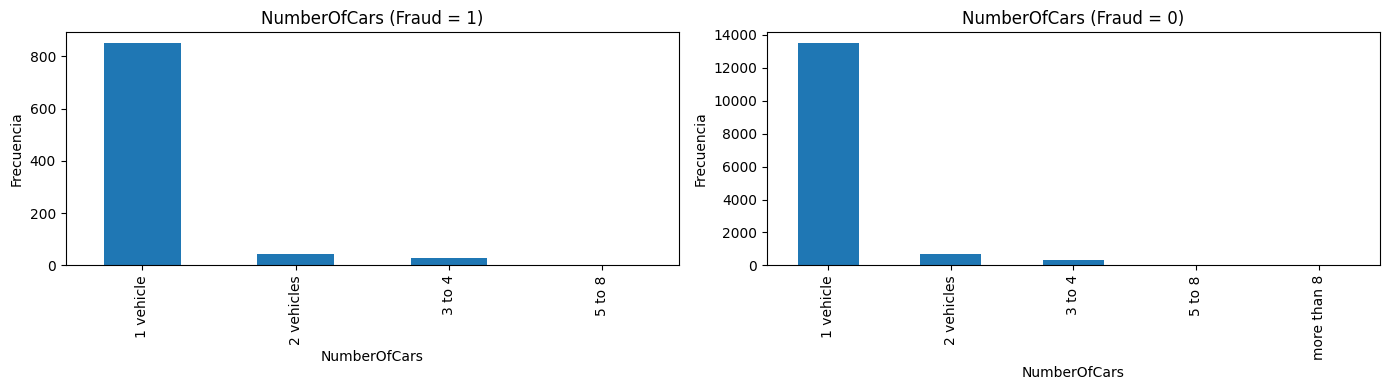

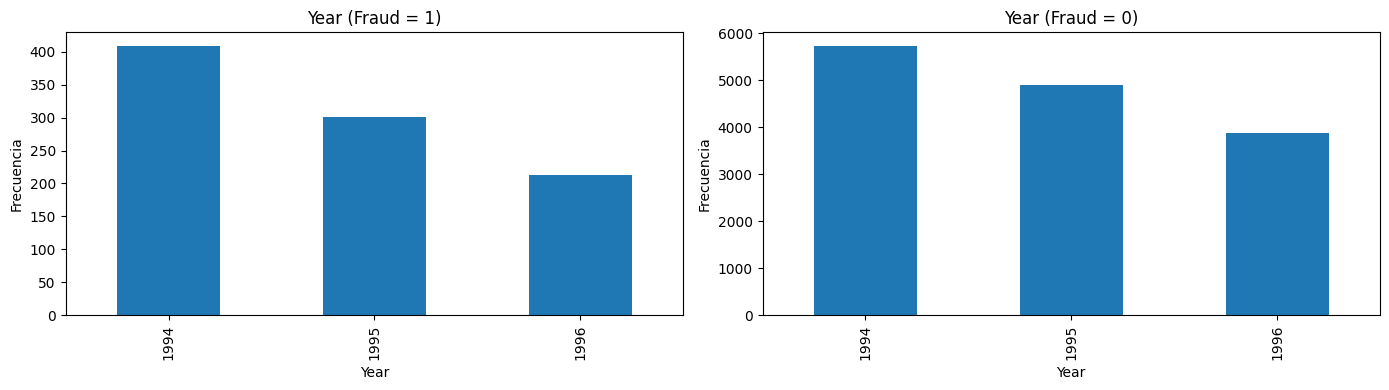

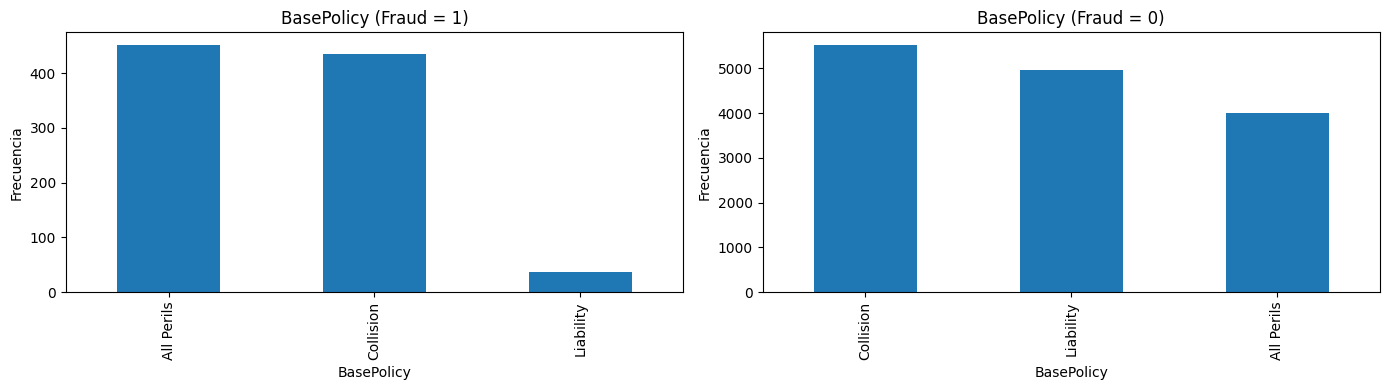

In [283]:
df_fraud = df[df['FraudFound_P'] == 1]
df_no_fraud = df[df['FraudFound_P'] == 0]

for col in df.columns:
    if col == "FraudFound_P":
        continue  # no graficamos la target

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ----------------------------------------
    #   Detectar si la columna es numérica
    # ----------------------------------------
    is_numeric = df[col].dtype.kind in "iuf"   # int, unsigned, float

    # ========================================
    #           FRAUD = 1
    # ========================================
    if col == "Age":
        # Histograma especial para Age
        axes[0].hist(df_fraud[col].dropna(), bins=20)

    elif is_numeric:
        # Ordenar por índice numérico ascendente
        df_fraud[col].value_counts(dropna=False).sort_index().plot(
            kind="bar", ax=axes[0]
        )

    else:
        # Categóricas → gráfico normal sin ordenar numéricamente
        df_fraud[col].value_counts(dropna=False).plot(kind="bar", ax=axes[0])

    axes[0].set_title(f"{col} (Fraud = 1)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")


    # ========================================
    #           FRAUD = 0
    # ========================================
    if col == "Age":
        axes[1].hist(df_no_fraud[col].dropna(), bins=20)

    elif is_numeric:
        df_no_fraud[col].value_counts(dropna=False).sort_index().plot(
            kind="bar", ax=axes[1]
        )

    else:
        df_no_fraud[col].value_counts(dropna=False).plot(kind="bar", ax=axes[1])

    axes[1].set_title(f"{col} (Fraud = 0)")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()


 Primeras observaciones: 
Vemos frecuencias distintas en las columnas:
1) Age vemos que en Fraud=1 hay menos personas en el rango de edad 25-30
2) Fault casi todos los que son fraude pertenecen a PolicyHolder y no fraude esta mas dividido con Third Party
3) Vehicle_Category vemos con son casi todos Sedan
4) Base Policy son casi todas All Perils y Collision. Liability aparece poco

## Feature Engineering

In [284]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Verano"
    elif month in [3, 4, 5]:
        return "Otonio"
    elif month in [6, 7, 8]:
        return "Invierno"
    elif month in [9, 10, 11]:
        return "Primavera"
    else:
        return None  # para valores erróneos
df['Season'] = df['Month'].apply(month_to_season)
df['Season_claimed'] = df['MonthClaimed'].apply(month_to_season)

In [285]:
df["IsWeekday"] = df["DayOfWeek"].apply(lambda x: 1 if x in [1,2,3,4,5] else 0)
df['IsWeekday_claimed'] = df["DayOfWeekClaimed"].apply(lambda x: 1 if x in [1,2,3,4,5] else 0)

In [286]:
df['Age25_35']=df['Age'].apply(lambda x: 1 if 25<=x<=35 else 0)

In [287]:
# Verificar que la edad este dentro del rango de AgeOfPolicyHolder. Puede no concordar ya que el duenio de la pliza puede ser mi papa y yo choque
def age_in_range(age, age_range):
    try:
        low, high = age_range.split(" to ")
        low = int(low)
        high = int(high)
        return low <= age <= high
    except:
        return False  # por si hay valores raros

mask = df.apply(lambda row: not age_in_range(row["Age"], row["AgeOfPolicyHolder"]), axis=1)

df_out_of_range = df[mask][["Age", "AgeOfPolicyHolder"]]
df["AgeInPolicyRange"] = df.apply(
    lambda row: 1 if age_in_range(row["Age"], row["AgeOfPolicyHolder"]) else 0,
    axis=1
)



In [288]:
df['Base_Policy_flag'] = df['BasePolicy'].apply(lambda x: 0 if x == 'Liability' else 1)

In [289]:
def add_time_diff_features(col_nueva,claimed,fecha,col_nueva_ciclica,num):
    # ---------- DÍA (ciclo 7) ----------
    df[col_nueva] = df[claimed] - df[fecha]
    abs = df[col_nueva].abs()
    df[col_nueva_ciclica] = np.minimum(abs, num - abs)
    return df

df = add_time_diff_features(col_nueva="diff_DayOfWeek",claimed="DayOfWeekClaimed",fecha="DayOfWeek",col_nueva_ciclica="diff_DayOfWeek_cyclic",num=7)
df = add_time_diff_features(col_nueva="diff_WeekOfMonth",claimed="WeekOfMonthClaimed",fecha="WeekOfMonth",col_nueva_ciclica="diff_WeekOfMonth_cyclic",num=5)
df = add_time_diff_features(  col_nueva="diff_Month",claimed="MonthClaimed",fecha="Month",col_nueva_ciclica="diff_Month_cyclic",num=12)

In [290]:
df = df.fillna(0)

## Optuna para maximizar AUC-PR

In [291]:
def objective(trial):

    print(f"\n🚀 Iniciando TRIAL {trial.number}")
    
    params = {
        "iterations": trial.suggest_int("iterations", 600, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pr_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"   ➤ Fold {fold+1}/5 del Trial {trial.number}")

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=False,
            **params
        )

        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            cat_features=cat_features,
            use_best_model=True
        )

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, y_pred_proba)
        pr_scores.append(score)

        trial.report(score, step=fold)
        if trial.should_prune():
            print(f"   ⚠️ Trial {trial.number} PRUNED en el fold {fold+1}")
            raise optuna.TrialPruned()

    avg_score = float(np.mean(pr_scores))
    print(f"✅ Trial {trial.number} COMPLETADO — AUC-PR promedio: {avg_score:.4f}")
    return avg_score

#study = optuna.create_study(direction="maximize")
#study.optimize(objective, n_trials=120)   # o el número que elijas



In [292]:
#Trial 102 finished with value: 0.27861352749157176 and parameters: {'iterations': 1686, 'depth': 7, 'learning_rate': 0.025896258282641225, 'l2_leaf_reg': 6.628520115352477, 'bagging_temperature': 6.852072457692241, 'border_count': 207, 'random_strength': 0.46370297054991977}. Best is trial 102 with value: 0.27861352749157176.

## Modelo con variables sacadas de optuna

In [ ]:
target = 'FraudFound_P'
X = df.drop(columns=[target])
y = df[target]

# Columnas categóricas
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pools
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)

# Modelo CatBoost optimizado para AUC-PR
#Trial 102 finished with value: 0.27861352749157176 and parameters: {'iterations': 1686, 'depth': 7, 'learning_rate': 0.025896258282641225, 'l2_leaf_reg': 6.628520115352477, 'bagging_temperature': 6.852072457692241, 'border_count': 207, 'random_strength': 0.46370297054991977}. Best is trial 102 with value: 0.27861352749157176.
model = CatBoostClassifier(
    iterations=1686,
    learning_rate=0.025896258282641225,
    depth=7,
    l2_leaf_reg= 6.628520115352477,
    bagging_temperature= 6.852072457692241,
    border_count= 207, 
    random_strength= 0.46370297054991977,
    loss_function= 'Logloss',
    auto_class_weights='Balanced', 
    eval_metric='AUC',     
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
    od_type= 'None'  # Por ahora mejor sin esto
)


model.fit(train_pool, eval_set=test_pool)

# Predicciones
y_pred = model.predict(X_test)

# Métrica importante
print("AUC-PR:", average_precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


0:	test: 0.7721087	best: 0.7721087 (0)	total: 175ms	remaining: 4m 55s
100:	test: 0.8680980	best: 0.8680980 (100)	total: 21.5s	remaining: 5m 37s
200:	test: 0.8732163	best: 0.8744171 (139)	total: 42.7s	remaining: 5m 15s
300:	test: 0.8754668	best: 0.8761810 (277)	total: 1m 3s	remaining: 4m 52s
400:	test: 0.8772046	best: 0.8777696 (365)	total: 1m 26s	remaining: 4m 36s
500:	test: 0.8784483	best: 0.8784669 (492)	total: 1m 50s	remaining: 4m 20s
600:	test: 0.8778311	best: 0.8789033 (517)	total: 2m 15s	remaining: 4m 5s
700:	test: 0.8771487	best: 0.8789033 (517)	total: 2m 39s	remaining: 3m 44s
800:	test: 0.8756402	best: 0.8789033 (517)	total: 3m 2s	remaining: 3m 21s
900:	test: 0.8751461	best: 0.8789033 (517)	total: 3m 25s	remaining: 2m 58s
1000:	test: 0.8742810	best: 0.8789033 (517)	total: 3m 47s	remaining: 2m 35s
1100:	test: 0.8729814	best: 0.8789033 (517)	total: 4m 11s	remaining: 2m 13s
1200:	test: 0.8722803	best: 0.8789033 (517)	total: 4m 41s	remaining: 1m 53s
1300:	test: 0.8711597	best: 0.87

Cambiar el threshold para comparar con modelo baseline

In [323]:
y_proba = model.predict_proba(X_test)[:, 1]

# Elegís el umbral que quieras (ejemplo: 0.51)
threshold = 0.17# acá lo cambiás a gusto

# Clasificación manual con ese umbral
y_pred_custom = (y_proba >= threshold).astype(int)

# Métricas
print("AUC-PR:", average_precision_score(y_test, y_proba))  # OJO: AUC-PR va con proba, no con 0/1
print(classification_report(y_test, y_pred_custom))

AUC-PR: 0.2831405160975211
              precision    recall  f1-score   support

           0       1.00      0.61      0.76      2899
           1       0.14      0.97      0.24       185

    accuracy                           0.63      3084
   macro avg       0.57      0.79      0.50      3084
weighted avg       0.95      0.63      0.73      3084



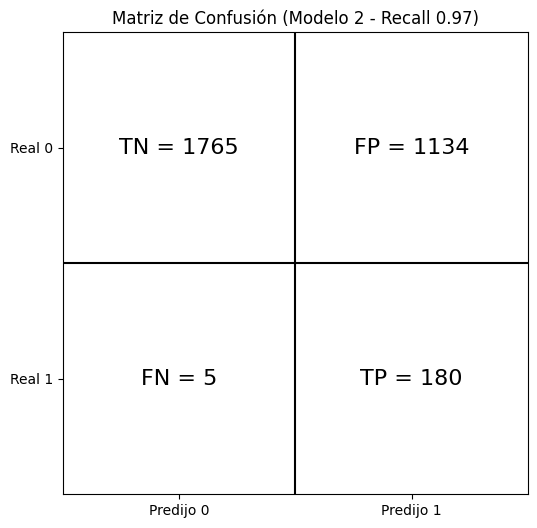

In [ ]:
cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 6))

# Líneas divisorias
ax.plot([0, 2], [1, 1], color='black')
ax.plot([1, 1], [0, 2], color='black')

# Etiquetas
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Predijo 0', 'Predijo 1'])
ax.set_yticklabels(['Real 0', 'Real 1'])

# Valores correctos en cada cuadrante
ax.text(0.5, 0.5, f"TN = {tn}", ha='center', va='center', fontsize=16)
ax.text(1.5, 0.5, f"FP = {fp}", ha='center', va='center', fontsize=16)
ax.text(0.5, 1.5, f"FN = {fn}", ha='center', va='center', fontsize=16)
ax.text(1.5, 1.5, f"TP = {tp}", ha='center', va='center', fontsize=16)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.invert_yaxis()

plt.title("Matriz de Confusión (Modelo 2 - Recall 0.97)")
plt.show()


In [297]:
df.dtypes.value_counts()

object     22
int64      17
float64     6
Name: count, dtype: int64

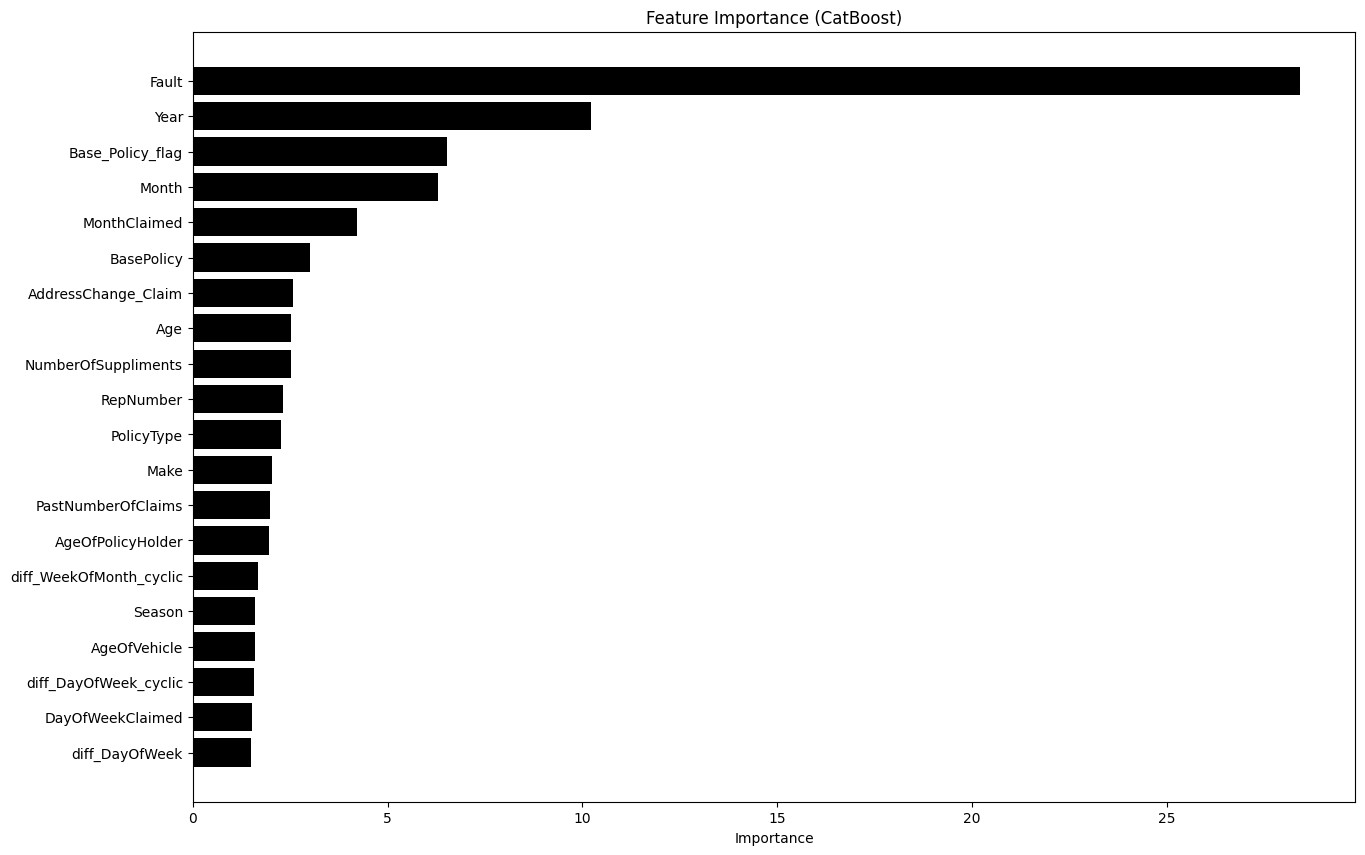

In [335]:
# Obtener importancias estándar
feature_importances = model.get_feature_importance()
features = X_train.columns

df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(20)

# Gráfico simple
plt.figure(figsize=(15, 10))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='black')
plt.xlabel('Importance')
plt.title('Feature Importance (CatBoost)')
plt.gca().invert_yaxis()  # Para que la más importante aparezca arriba
plt.show()


CatBoostError: Feature importance type EFstrType.LossFunctionChange requires training dataset                             to be passed to this function.